# Binocular Rivalry VR Experiment: 1-to-1 Task & Proposition Analysis

This notebook analyzes the 4 experimental tasks, with each task specifically designed to evaluate one of the modernized **Levelt Propositions** (Brascamp, Klink, & Levelt, 2015):

| Task | Modality | Target Proposition | Core Metric |
|   :---     | :--- | :--- | :--- |
| **Task 1** | Holding (Unilateral) | **Proposition I**: Increasing stimulus strength increases predominance | **Predominance / Dominance %** |
| **Task 2** | Holding (Unilateral) | **Proposition II**: Increasing interocular difference increases duration of stronger stimulus | **Mean Dominance Duration** |
| **Task 3** | Tapping (Unilateral) | **Proposition III**: Increasing interocular difference reduces alternation rate | **Alternation Rate vs. Difference** |
| **Task 4** | Tapping (Bilateral) | **Proposition IV**: Bilateral strength increase generally increases alternation rate | **Alternation Rate vs. Bilateral Contrast** |

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure analyzer module can be imported regardless of execution working directory
cwd = Path.cwd()
for p in [cwd, cwd / "Analysis", cwd.parent / "Analysis"]:
    if (p / "analyzer.py").is_file() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

import analyzer

# Configure visual styling
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

print("Analyzer module loaded successfully!")

Analyzer module loaded successfully!


## 1. Data Ingestion

Loads all `participant_{id}_task_{task}.json` files from the project-level `Data/` directory.

In [2]:
data_dir = analyzer.get_data_dir()
print(f"Using data directory: {data_dir}")

raw_trials = analyzer.load_all_trials(data_dir)
print(f"Total trials loaded: {len(raw_trials)}")

if len(raw_trials) == 0:
    print("Warning: No trial JSON files found in data_dir. Check that participant_*.json files exist in:", data_dir)
else:
    df = analyzer.build_summary_dataframe(raw_trials)
    print("\nTasks detected in dataset:", sorted(df["taskType"].unique().tolist()))
    display(df.head(10))

Using data directory: /mnt/d/Unity/vr-perceptual-experiment/Data
  - Loaded 10 trial(s) from participant_1_task_1.json
  - Loaded 10 trial(s) from participant_1_task_2.json
  - Loaded 10 trial(s) from participant_1_task_3.json
  - Loaded 10 trial(s) from participant_1_task_4.json
Total trials loaded: 40

Tasks detected in dataset: [1, 2, 3, 4]


,participantID,taskType,trialNumber,isControl,contrastL,contrastR,variableEye,contrastVariable,contrastFixed,contrastDifference,...,predominanceWeaker,meanDurationLeftMs,meanDurationRightMs,meanDurationPiecemealMs,meanDurationVariableMs,meanDurationFixedMs,meanDurationStrongerMs,meanDurationWeakerMs,switchCount,switchRatePerMin
0,1,1,1,False,0.5,0.9,right,0.9,0.5,0.4,...,20.894824,774.527330,733.065747,NaN,733.065747,774.527330,733.065747,774.527330,4,24.0
1,1,1,2,False,0.7,0.5,left,0.7,0.5,0.2,...,0.000000,769.715660,NaN,245.422360,769.715660,NaN,769.715660,NaN,4,24.0
2,1,1,3,False,0.3,0.5,left,0.3,0.5,0.2,...,54.839297,1152.856845,NaN,949.389000,1152.856845,NaN,NaN,1152.856845,5,30.0
3,1,1,4,False,0.9,0.5,left,0.9,0.5,0.4,...,55.062838,196.769000,459.664954,559.636557,196.769000,459.664954,196.769000,459.664954,9,54.0
4,1,1,5,False,0.5,0.5,equal,0.5,0.5,0.0,...,22.611732,335.090993,NaN,608.814165,NaN,NaN,NaN,NaN,9,54.0
5,1,1,6,False,0.5,0.1,right,0.1,0.5,0.4,...,0.000000,571.775684,NaN,NaN,NaN,571.775684,571.775684,NaN,5,30.0
6,1,1,7,False,0.5,0.5,equal,0.5,0.5,0.0,...,0.000000,NaN,NaN,451.220984,NaN,NaN,NaN,NaN,8,48.0
7,1,1,8,True,0.5,0.3,right,0.3,0.5,0.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,18.0
8,1,1,9,True,0.7,0.5,left,0.7,0.5,0.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,36.0
9,1,1,10,False,0.5,0.5,equal,0.5,0.5,0.0,...,35.907153,307.453178,174.301440,275.543500,240.877309,240.877309,240.877309,240.877309,8,48.0


In [3]:
# Separate rivalry and control trials here and to be used here on after for each task instead of the whole df
rivalry_df = df[df["isControl"] == False].copy()
print(f"Total trials: {len(df)}")
print(f"Rivalry trials (isControl=False): {len(rivalry_df)}")
print(f"Control trials excluded: {len(df) - len(rivalry_df)}")
display(rivalry_df.groupby(["taskType", "isControl"]).size().reset_index(name="count"))

Total trials: 40
Rivalry trials (isControl=False): 34
Control trials excluded: 6


,taskType,isControl,count
0,1,False,8
1,2,False,10
2,3,False,9
3,4,False,7


## 2. Sample Trial Timeline (Perceptual Raster Plot)

Visualizes the temporal sequence of dominance intervals, transitions, and piecemeal states for an individual trial.

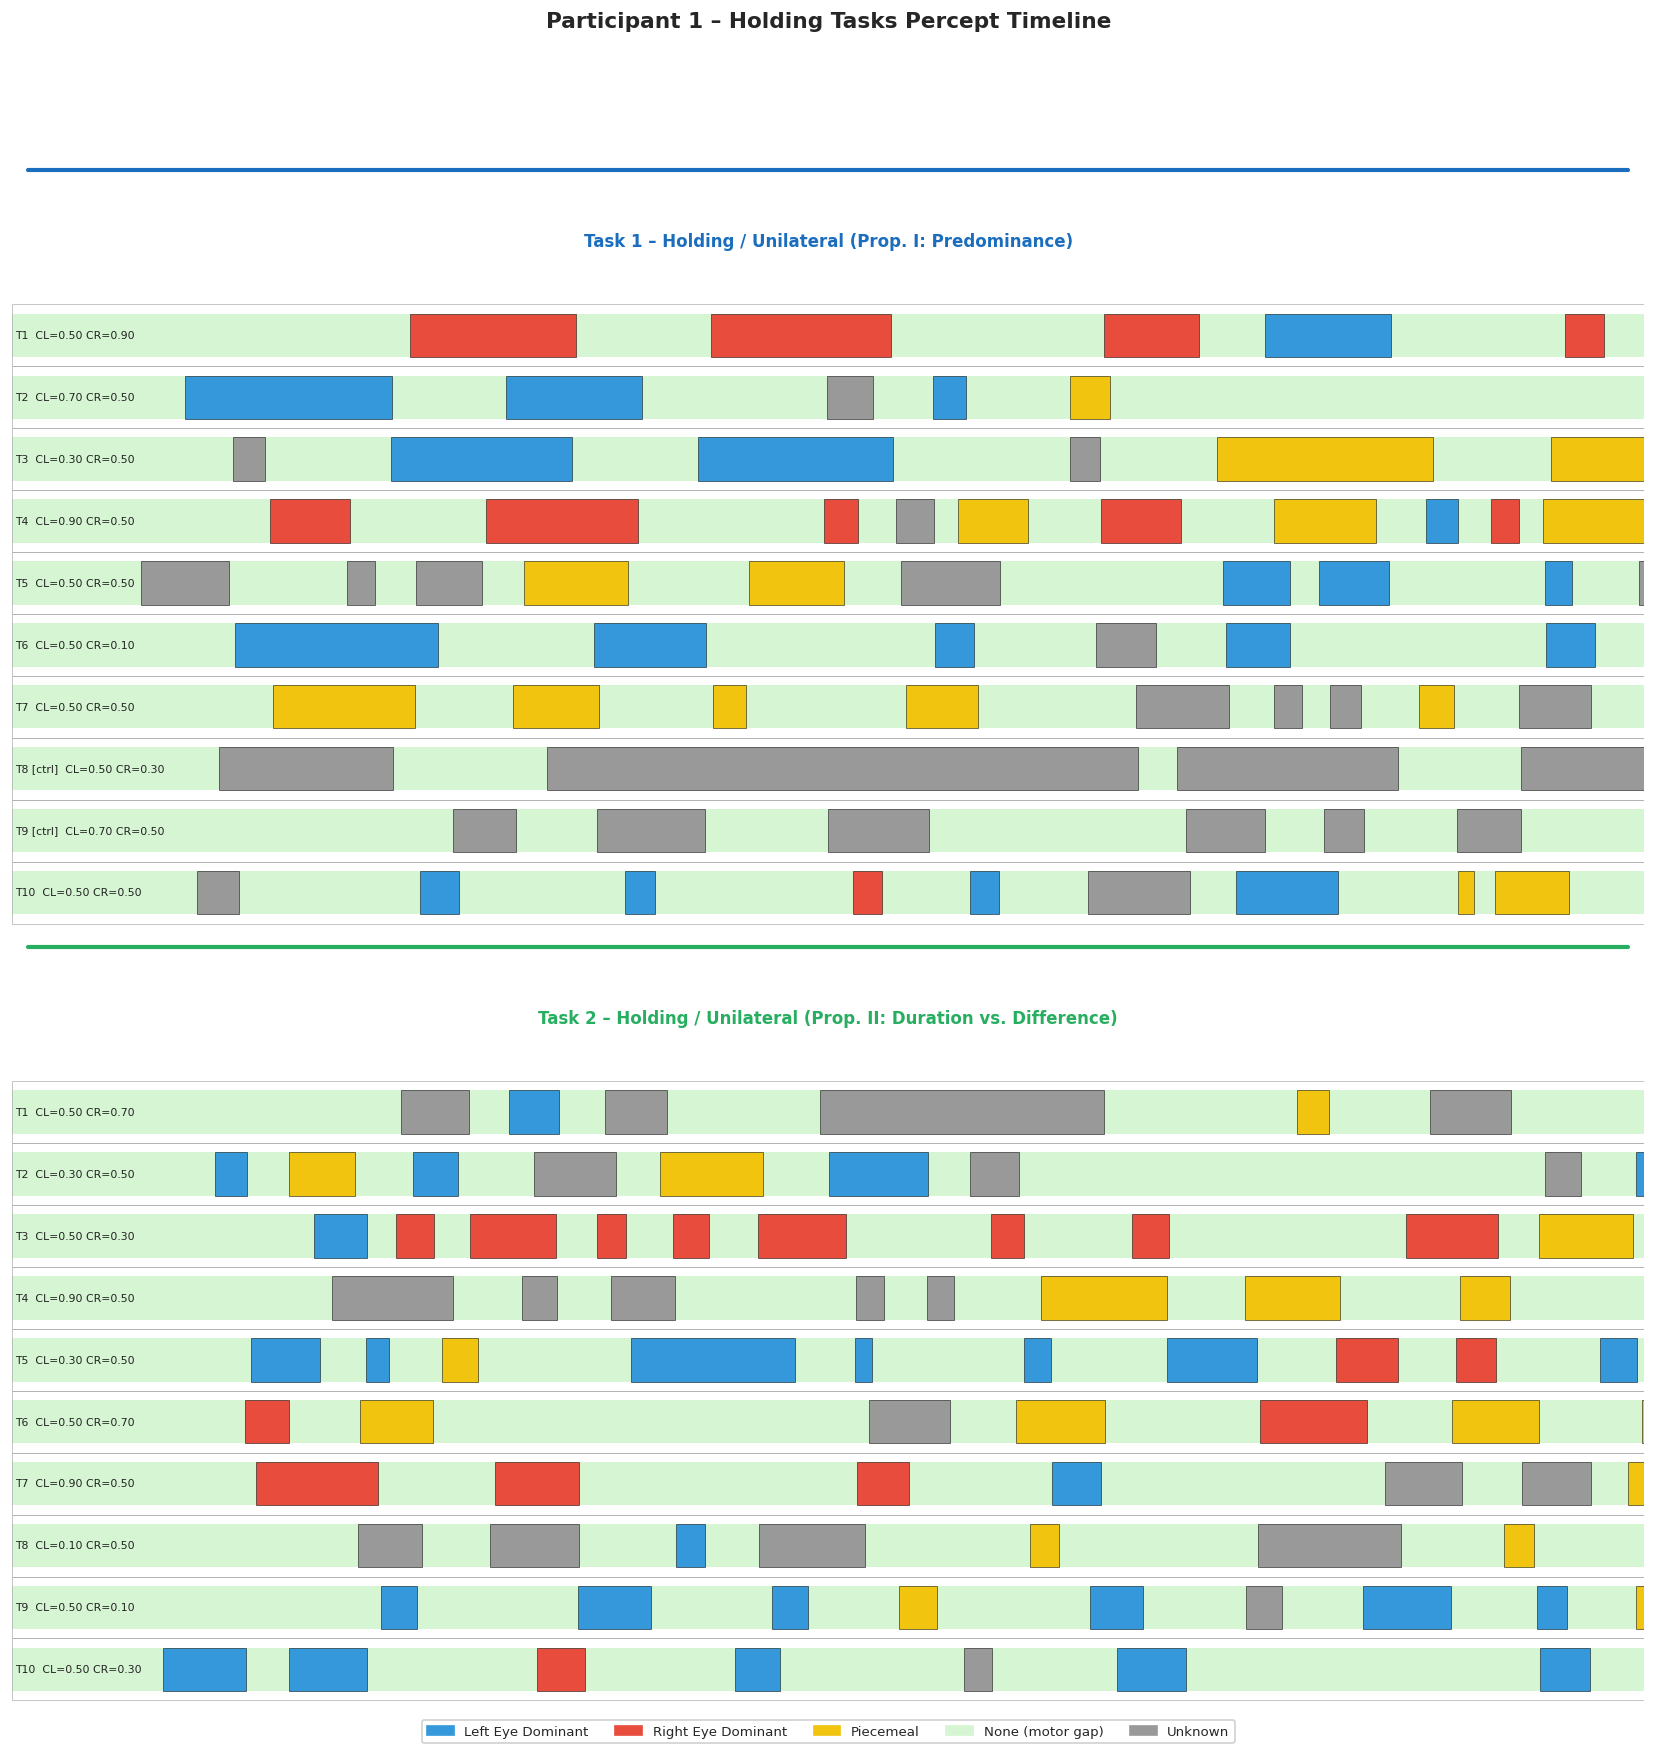

In [4]:
# Filter to continuous holding tasks (Tasks 1 and 2) where timelines make sense
holding_trials = [t for t in raw_trials if t.get("taskType", 1) in (1, 2)]

# Generate the timeline dashboard
part_id = holding_trials[0].get('participantID', '?') if holding_trials else '?'

fig_timeline = analyzer.plot_all_trials_timeline(
    holding_trials,
    title=f"Participant {part_id} – Holding Tasks Percept Timeline",
)
plt.show()

## 3. Task 1 $\rightarrow$ Proposition I: Stimulus Strength & Predominance

> **Proposition I**:
> *Increasing stimulus strength for one eye will increase the perceptual predominance of that eye’s stimulus.*

Evaluated using **Task 1** (Continuous Holding, Unilateral contrast manipulation).
Predominance is calculated as: $\left(\frac{\sum \text{Dominance Time}}{\text{Total Trial Duration}}\right) \times 100$.

Task 1: Predominance vs. Variable Eye Contrast:


,contrastVariable,predominanceVariable,predominanceFixed,dominancePctPiecemeal
0,0.1,0.000000,100.000000,0.000000
1,0.3,54.839297,0.000000,45.160703
2,0.5,36.041005,2.971586,60.987410
3,0.7,90.392809,0.000000,9.607191
4,0.9,41.909665,37.978831,20.111503


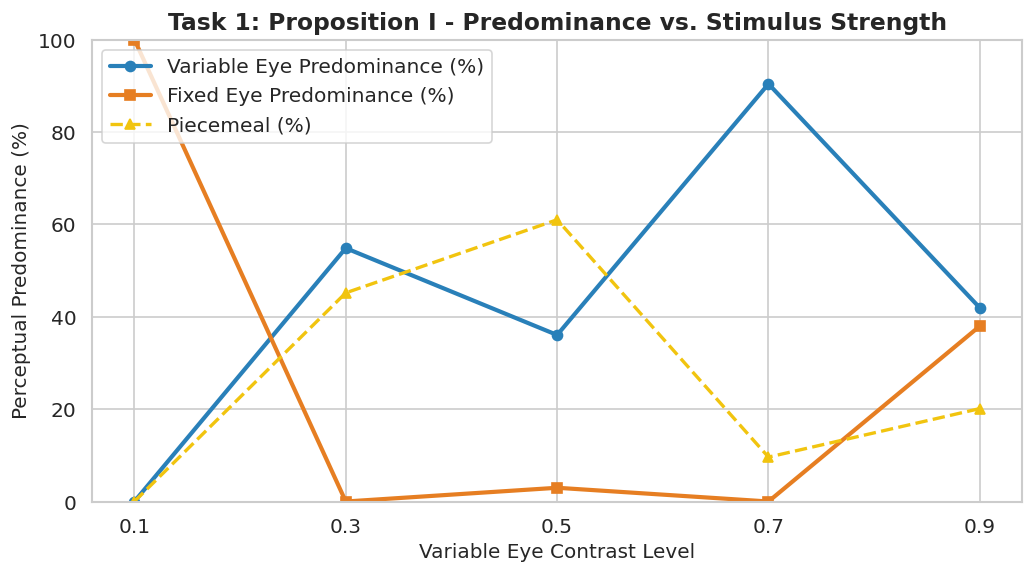

In [5]:
if 'df' in locals() and not df.empty:
    t1_df = rivalry_df[rivalry_df["taskType"] == 1]
    if not t1_df.empty:
        summary_p1 = t1_df.groupby("contrastVariable")[["predominanceVariable", "predominanceFixed", "dominancePctPiecemeal"]].mean().reset_index()
        print("Task 1: Predominance vs. Variable Eye Contrast:")
        display(summary_p1)

        plt.figure(figsize=(10, 5))
        plt.plot(summary_p1["contrastVariable"], summary_p1["predominanceVariable"], marker="o", color="#2980b9", lw=2.5, label="Variable Eye Predominance (%)")
        plt.plot(summary_p1["contrastVariable"], summary_p1["predominanceFixed"], marker="s", color="#e67e22", lw=2.5, label="Fixed Eye Predominance (%)")
        plt.plot(summary_p1["contrastVariable"], summary_p1["dominancePctPiecemeal"], marker="^", color="#f1c40f", lw=2, linestyle="--", label="Piecemeal (%)")
        plt.title("Task 1: Proposition I - Predominance vs. Stimulus Strength", fontsize=14, fontweight="bold")
        plt.xlabel("Variable Eye Contrast Level", fontsize=12)
        plt.ylabel("Perceptual Predominance (%)", fontsize=12)
        plt.xticks([0.1, 0.3, 0.5, 0.7, 0.9])
        plt.ylim(0, 100)
        plt.legend()
        plt.show()
    else:
        print("No Task 1 data loaded yet. Run Task 1 in Unity to populate this section.")

## 4. Task 2 $\rightarrow$ Proposition II: Contrast Difference & Dominance Duration of the Stronger Stimulus

> **Proposition II**:
> *Increasing the difference in stimulus strength between the two eyes will primarily act to increase the average perceptual dominance duration of the stronger stimulus.*

Evaluated using **Task 2** (Continuous Holding, tracking individual episode durations across contrast differences $\Delta C = |C_L - C_R|$).

Task 2: Mean Dominance Durations across Interocular Difference |CL - CR|:


,contrastVariable,meanDurationVariableMs,meanDurationFixedMs
0,0.1,176.155030,322.627922
1,0.3,321.226935,344.184576
2,0.7,460.677900,311.240680
3,0.9,294.609510,529.223140


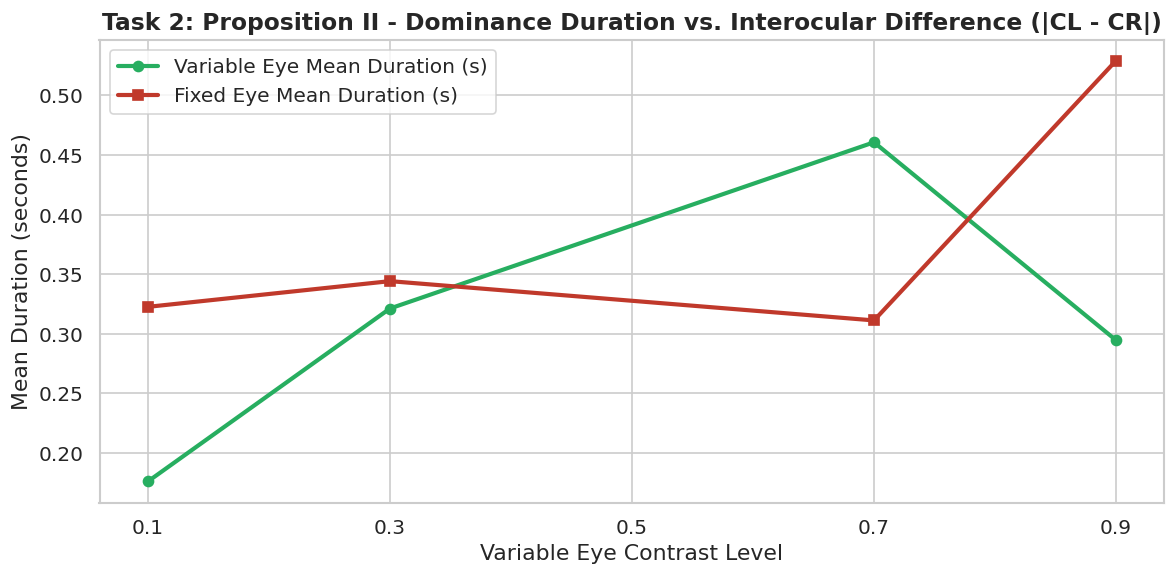

In [6]:
if 'df' in locals() and not df.empty:
    t2_df = rivalry_df[rivalry_df["taskType"] == 2]
    if not t2_df.empty:
        summary_p2 = t2_df.groupby("contrastVariable")[["meanDurationVariableMs", "meanDurationFixedMs"]].mean().reset_index()
        print("Task 2: Mean Dominance Durations across Interocular Difference |CL - CR|:")
        display(summary_p2)
        
        plt.figure(figsize=(10, 5))
        plt.plot(summary_p2["contrastVariable"], summary_p2["meanDurationVariableMs"] / 1000.0, marker="o", lw=2.5, color="#27ae60", label="Variable Eye Mean Duration (s)")
        plt.plot(summary_p2["contrastVariable"], summary_p2["meanDurationFixedMs"] / 1000.0, marker="s", lw=2.5, color="#c0392b", label="Fixed Eye Mean Duration (s)")
        plt.title("Task 2: Proposition II - Dominance Duration vs. Interocular Difference (|CL - CR|)", fontsize=14, fontweight="bold")
        plt.xlabel("Variable Eye Contrast Level")
        plt.ylabel("Mean Duration (seconds)")
        plt.xticks([0.1, 0.3, 0.5, 0.7, 0.9])
        plt.legend()
        plt.tight_layout()
    else:
        print("No Task 2 data loaded yet. Run Task 2 in Unity to populate this section.")

## 5. Task 3 $\rightarrow$ Proposition III: Contrast Difference & Alternation Rate

> **Proposition III**:
> *Increasing the difference in stimulus strength between the two eyes will reduce the perceptual alternation rate.*

Evaluated using **Task 3** (Discrete Switch Tapping, Unilateral contrast manipulation).
Evaluates how alternation rate (switches / minute) responds to changes in contrast difference $\Delta C = |C_L - C_R|$.

Task 3: Alternation Rate across Interocular Difference |CL - CR|:


,contrastVariable,switchRatePerMin
0,0.1,21.0
1,0.3,18.0
2,0.5,27.0
3,0.7,36.0
4,0.9,30.0


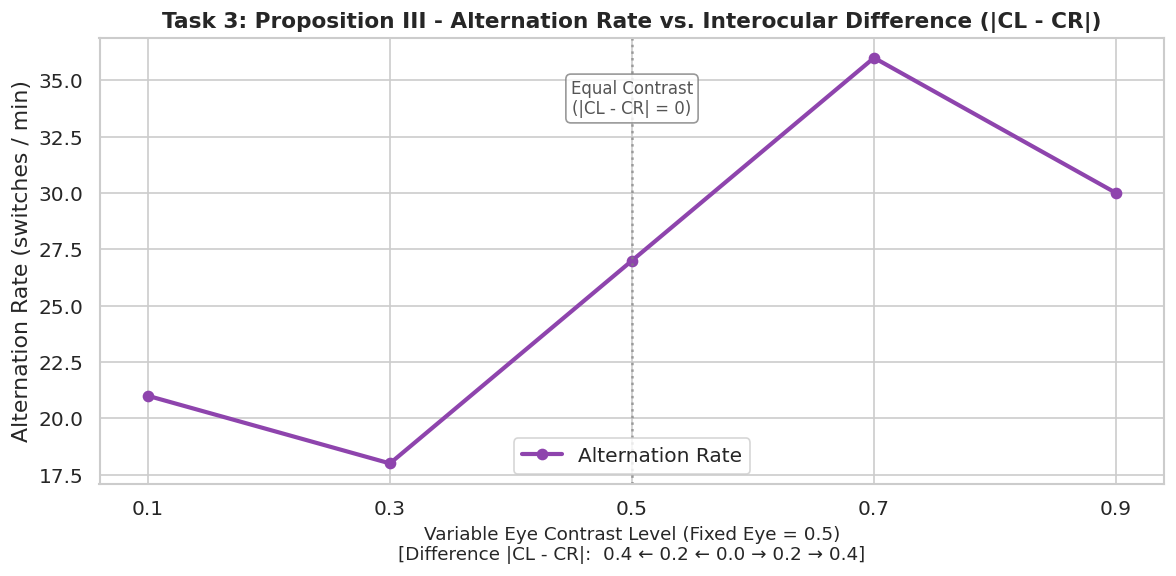

In [7]:
if 'df' in locals() and not df.empty:
    t3_df = rivalry_df[rivalry_df["taskType"] == 3]
    if not t3_df.empty:
        summary_p3 = t3_df.groupby("contrastVariable")["switchRatePerMin"].mean().reset_index()
        print("Task 3: Alternation Rate across Interocular Difference |CL - CR|:")
        display(summary_p3)
        
        plt.figure(figsize=(10, 5))
        plt.plot(summary_p3["contrastVariable"], summary_p3["switchRatePerMin"], 
                marker="o", color="#8e44ad", lw=2.5, label="Alternation Rate")
        
        # Highlight the zero-difference reference
        plt.axvline(x=0.5, color="gray", linestyle=":", alpha=0.7)
        plt.text(0.5, plt.ylim()[1] * 0.95, "Equal Contrast\n(|CL - CR| = 0)", 
                ha="center", va="top", fontsize=10, color="#555555",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
        
        plt.title("Task 3: Proposition III - Alternation Rate vs. Interocular Difference (|CL - CR|)", fontsize=13, fontweight="bold")
        plt.xlabel("Variable Eye Contrast Level (Fixed Eye = 0.5)\n[Difference |CL - CR|:  0.4 ← 0.2 ← 0.0 → 0.2 → 0.4]", fontsize=11)
        plt.ylabel("Alternation Rate (switches / min)")
        plt.xticks([0.1, 0.3, 0.5, 0.7, 0.9])
        plt.legend(loc="lower center")
        plt.tight_layout()
        plt.show()
    else:
        print("No Task 3 data loaded yet. Run Task 3 in Unity to populate this section.")

## 6. Task 4 $\rightarrow$ Proposition IV: Bilateral Contrast & Alternation Rate

> **Proposition IV**:
> *Increasing stimulus strength in both eyes while keeping it equal between eyes will generally increase the perceptual alternation rate, but this effect may reverse at near-threshold stimulus strengths.*

Evaluated using **Task 4** (Discrete Switch Tapping, Bilateral contrast manipulation where $C_L = C_R$ across $0.1 \rightarrow 0.9$).

Task 4: Alternation Rate across Equal Bilateral Contrast:


,contrastL,switchRatePerMin
0,0.3,21.0
1,0.5,42.0
2,0.7,32.0
3,0.9,30.0


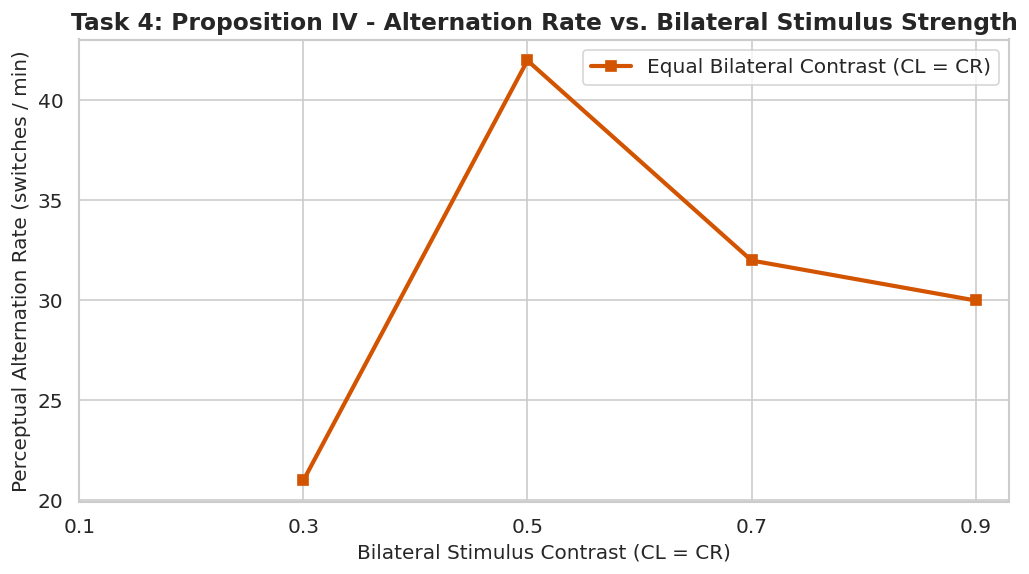

In [8]:
if 'df' in locals() and not df.empty:
    t4_df = rivalry_df[rivalry_df["taskType"] == 4]
    if not t4_df.empty:
        summary_p4 = t4_df.groupby("contrastL")["switchRatePerMin"].mean().reset_index()
        print("Task 4: Alternation Rate across Equal Bilateral Contrast:")
        display(summary_p4)
        
        plt.figure(figsize=(10, 5))
        plt.plot(summary_p4["contrastL"], summary_p4["switchRatePerMin"], marker="s", color="#d35400", lw=2.5, label="Equal Bilateral Contrast (CL = CR)")
        plt.title("Task 4: Proposition IV - Alternation Rate vs. Bilateral Stimulus Strength", fontsize=14, fontweight="bold")
        plt.xlabel("Bilateral Stimulus Contrast (CL = CR)", fontsize=12)
        plt.ylabel("Perceptual Alternation Rate (switches / min)", fontsize=12)
        plt.xticks([0.1, 0.3, 0.5, 0.7, 0.9])
        plt.legend()
        plt.show()
    else:
        print("No Task 4 data loaded yet. Run Task 4 in Unity to populate this section.")

## 7. Catch / Control Trials Analysis

In control trials (`isControl == True`), identical stimuli are presented to both eyes to verify participant attention and baseline response accuracy.

In [9]:
if 'df' in locals() and not df.empty:
    ctrl_summary = df.groupby("isControl")[["dominancePctTotal", "dominancePctPiecemeal", "switchCount"]].mean().reset_index()
    ctrl_summary["isControl"] = ctrl_summary["isControl"].map({True: "Control (Identical Stimuli)", False: "Rivalry (Divergent Stimuli)"})
    print("Comparison: Control vs. Rivalry Trials")
    display(ctrl_summary)

Comparison: Control vs. Rivalry Trials


,isControl,dominancePctTotal,dominancePctPiecemeal,switchCount
0,Rivalry (Divergent Stimuli),69.774344,30.225656,5.764706
1,Control (Identical Stimuli),0.000000,100.000000,3.000000


## 8. Export Consolidated Dataset

Export the computed metrics across all participants and trials to a clean CSV file (`perceptual_metrics_summary.csv`) for formal statistical analysis (e.g. repeated-measures ANOVA in SPSS, R, or Jamovi).

In [10]:
if 'df' in locals() and not df.empty:
    output_csv = "perceptual_metrics_summary.csv"
    df.to_csv(output_csv, index=False)
    print(f"Dataset exported successfully to: {os.path.abspath(output_csv)}")
    print(f"Total trials: {len(df)}, Columns: {len(df.columns)}")

Dataset exported successfully to: /mnt/d/Unity/vr-perceptual-experiment/Analysis/perceptual_metrics_summary.csv
Total trials: 40, Columns: 35
